Cell 1: Clean train/test spli

In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, average_precision_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import joblib

feature_df = pd.read_parquet("data/processed/feature_df.parquet").copy()

feature_df = feature_df.sort_values(["day", "user"]).reset_index(drop=True)

leak_cols = [
    "after_hours_events",
    "user_mean_after",
    "user_std_after",
    "after_hours_events_dev",
    "after_hours_ratio",
]
mean_std_cols = [c for c in feature_df.columns if c.startswith("user_mean_") or c.startswith("user_std_")]
drop_cols = list(set(leak_cols + mean_std_cols + ["user", "day", "employee_name", "email", "projects", "total_events"]))

df = feature_df.drop(columns=[c for c in drop_cols if c in feature_df.columns]).copy()

y = df.pop("is_insider").astype(int)

cat_cols = [c for c in ["role", "functional_unit", "department", "team", "supervisor"] if c in df.columns]
df = pd.get_dummies(df, columns=cat_cols, drop_first=False)

split_idx = int(len(df) * 0.8)
X_train = df.iloc[:split_idx].copy()
X_test = df.iloc[split_idx:].copy()
y_train = y.iloc[:split_idx].copy()
y_test = y.iloc[split_idx:].copy()

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("Train positives:", int(y_train.sum()), "Test positives:", int(y_test.sum()))

Train shape: (1115208, 434) Test shape: (278802, 434)
Train positives: 6 Test positives: 19


Cell 2: Model training code

In [2]:
def eval_model(name, model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    cm = confusion_matrix(y_test, pred)
    return {
        "model": name,
        "tn": cm[0, 0],
        "fp": cm[0, 1],
        "fn": cm[1, 0],
        "tp": cm[1, 1],
        "precision": classification_report(y_test, pred, output_dict=True, zero_division=0)["1"]["precision"],
        "recall": classification_report(y_test, pred, output_dict=True, zero_division=0)["1"]["recall"],
        "f1": classification_report(y_test, pred, output_dict=True, zero_division=0)["1"]["f1-score"],
        "roc_auc": roc_auc_score(y_test, proba),
        "pr_auc": average_precision_score(y_test, proba),
        "y_proba": proba,
    }

lr = LogisticRegression(class_weight="balanced", max_iter=5000)
rf = RandomForestClassifier(n_estimators=300, random_state=42, class_weight="balanced", n_jobs=-1)
xgb = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    random_state=42,
    scale_pos_weight=10
)

lr_res = eval_model("Logistic Regression", lr, X_train, y_train, X_test, y_test)
rf_res = eval_model("Random Forest", rf, X_train, y_train, X_test, y_test)
xgb_res = eval_model("XGBoost", xgb, X_train, y_train, X_test, y_test)

results_df = pd.DataFrame([lr_res, rf_res, xgb_res]).drop(columns=["y_proba"])
results_df

,model,tn,fp,fn,tp,precision,recall,f1,roc_auc,pr_auc
0,Logistic Regression,278779,4,0,19,0.826087,1.000000,0.904762,0.999993,0.826087
1,Random Forest,278779,4,3,16,0.800000,0.842105,0.820513,0.999992,0.869516
2,XGBoost,278779,4,0,19,0.826087,1.000000,0.904762,0.999991,0.846081


In [3]:
X_train.to_csv("data/processed/X_train.csv", index=False)
X_test.to_csv("data/processed/X_test.csv", index=False)
X_train.to_parquet("data/processed/X_train.parquet", index=False)
X_test.to_parquet("data/processed/X_test.parquet", index=False)

y_train.to_csv("data/processed/y_train.csv", index=False)
y_test.to_csv("data/processed/y_test.csv", index=False)
# y_train.to_parquet("data/processed/y_train.parquet", index=False)
# y_test.to_parquet("data/processed/y_test.parquet", index=False)

# joblib.dump(xgb, "data/models/xgb_temporal.joblib")

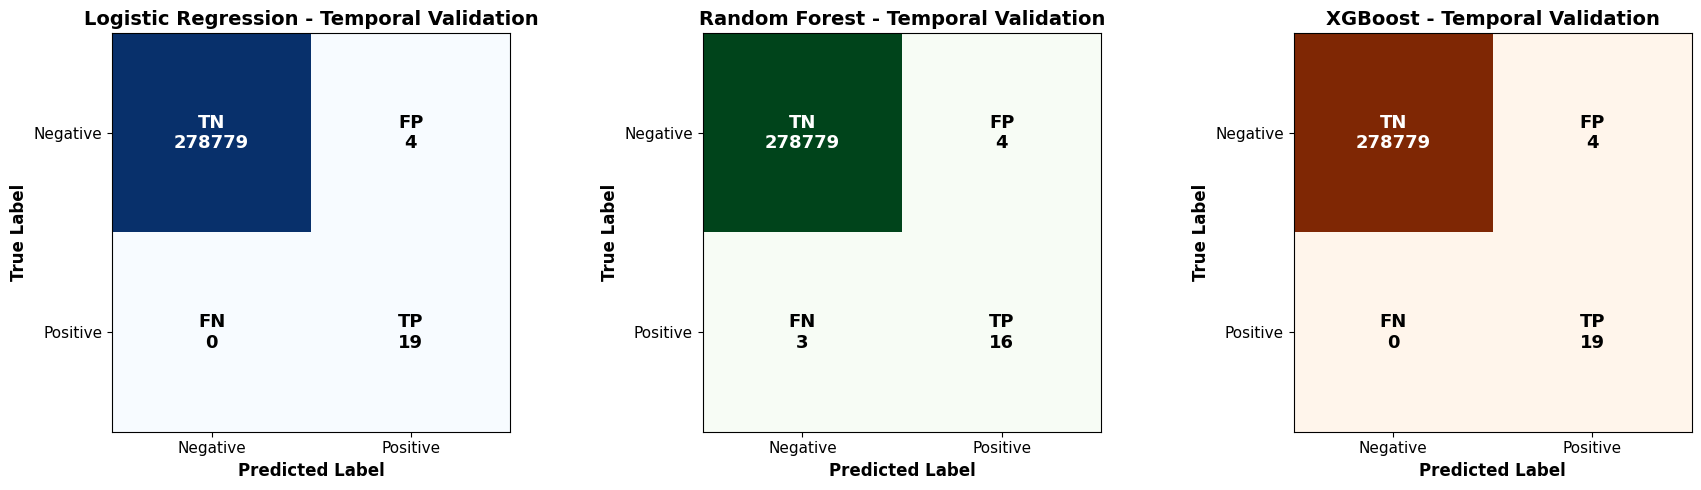

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

# --- Fit models and get predictions ---
lr.fit(X_train, y_train)
rf.fit(X_train, y_train)
xgb.fit(X_train, y_train)

lr_pred = lr.predict(X_test)
rf_pred = rf.predict(X_test)
xgb_pred = xgb.predict(X_test)

# --- Models and colormaps ---
models = {
    "Logistic Regression": (lr_pred, "Blues"),
    "Random Forest": (rf_pred, "Greens"),
    "XGBoost": (xgb_pred, "Oranges")
}

# Labels for confusion matrix cells
labels = np.array([
    ["TN", "FP"],
    ["FN", "TP"]
])

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, (pred, cmap)) in zip(axes, models.items()):

    cm = confusion_matrix(y_test, pred)

    # Plot confusion matrix
    ax.imshow(cm, interpolation="nearest", cmap=cmap)

    # Axis ticks
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Negative", "Positive"], fontsize=11)
    ax.set_yticklabels(["Negative", "Positive"], fontsize=11)

    # Axis labels and title
    ax.set_xlabel("Predicted Label", fontsize=12, fontweight="bold")
    ax.set_ylabel("True Label", fontsize=12, fontweight="bold")
    ax.set_title(f"{name} - Temporal Validation", fontsize=14, fontweight="bold")

    # Add TN, FP, FN, TP labels with counts
    thresh = cm.max() / 2

    for i in range(2):
        for j in range(2):
            color = "white" if cm[i, j] > thresh else "black"
            ax.text(
                j, i,
                f"{labels[i, j]}\n{cm[i, j]}",
                ha="center",
                va="center",
                fontsize=13,
                fontweight="bold",
                color=color
            )

plt.tight_layout()

plt.savefig(
    "data/visualizations/LR_RF_XGB_Temporal_Confusion_Matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, precision_score, recall_score

def plot_custom_cm(y_true, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    tn_pct = tn / (tn + fp) * 100 if (tn + fp) > 0 else 0
    fp_pct = fp / (tn + fp) * 100 if (tn + fp) > 0 else 0
    fn_pct = fn / (fn + tp) * 100 if (fn + tp) > 0 else 0
    tp_pct = tp / (fn + tp) * 100 if (fn + tp) > 0 else 0

    sensitivity = recall_score(y_true, y_pred) * 100
    specificity = tn / (tn + fp) * 100 if (tn + fp) > 0 else 0
    precision = precision_score(y_true, y_pred, zero_division=0) * 100

    fig, ax = plt.subplots(figsize=(8, 8))
    fig.patch.set_facecolor('#e6e6e6')
    ax.set_facecolor('#e6e6e6')

    colors = np.array([
        ['#006d2c', '#c0002b'],
        ['#c0002b', '#c0002b']
    ])

    for i in range(2):
        for j in range(2):
            rect = plt.Rectangle((j, 1 - i), 1, 1, facecolor=colors[i, j], edgecolor='black', linewidth=3)
            ax.add_patch(rect)

    labels = [
        [f"TN: {tn_pct:.2f}%\n\n{tn}", f"FP: {fp_pct:.2f}%\n\n{fp}"],
        [f"FN: {fn_pct:.1f}%\n\n{fn}", f"TP: {tp_pct:.1f}%\n\n{tp}"]
    ]

    for i in range(2):
        for j in range(2):
            ax.text(j + 0.5, 1.5 - i, labels[i][j],
                    ha='center', va='center',
                    color='white', fontsize=17, fontweight='bold')

    ax.set_xlim(0, 2)
    ax.set_ylim(0, 2)
    ax.set_xticks([0.5, 1.5])
    ax.set_yticks([1.5, 0.5])
    ax.set_xticklabels(['Predicted Normal', 'Predicted Malicious'], fontsize=15)
    ax.set_yticklabels(['Actual Normal', 'Actual Malicious'], fontsize=15, rotation=90, va='center')
    ax.set_title(title, fontsize=22, fontweight='bold', pad=15)

    metrics_text = f"Sensitivity: {sensitivity:.1f}% | Specificity: {specificity:.1f}% | Precision: {precision:.1f}%"
    fig.text(0.5, 0.03, metrics_text,
             ha='center', va='center',
             fontsize=17, fontweight='bold',
             bbox=dict(boxstyle="round,pad=0.25", facecolor="#b7d1df", edgecolor="#4d4d4d"))

    plt.tight_layout(rect=[0.02, 0.06, 1, 1])
    plt.show()

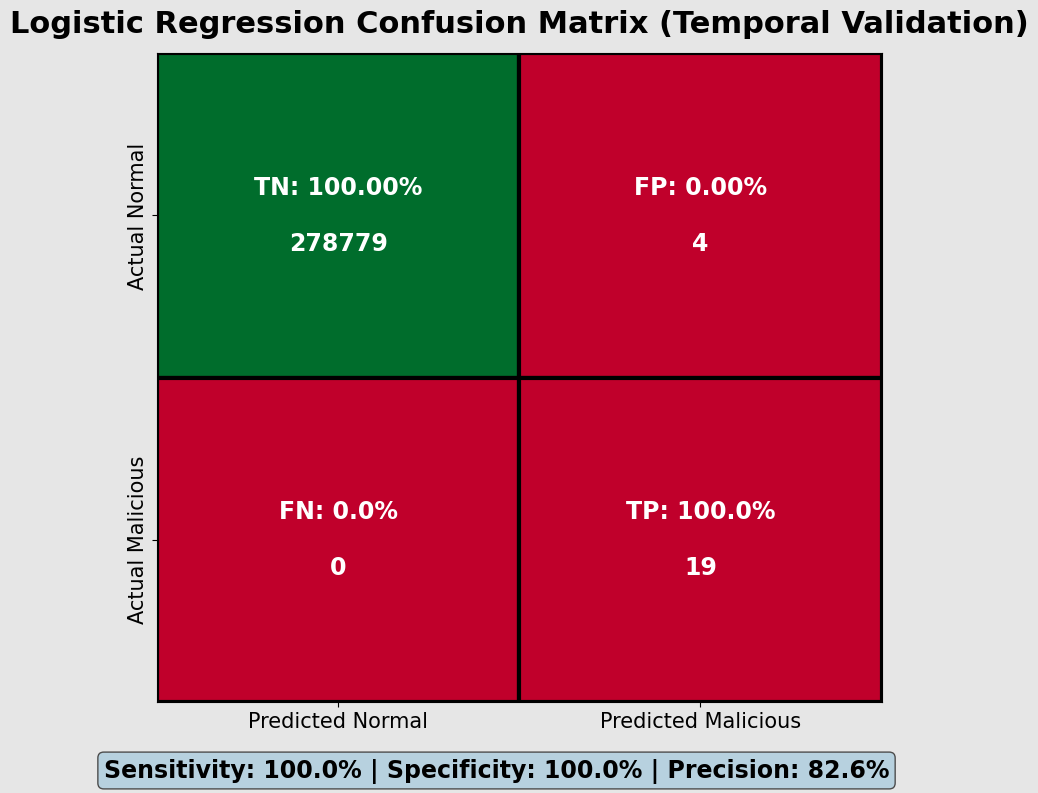

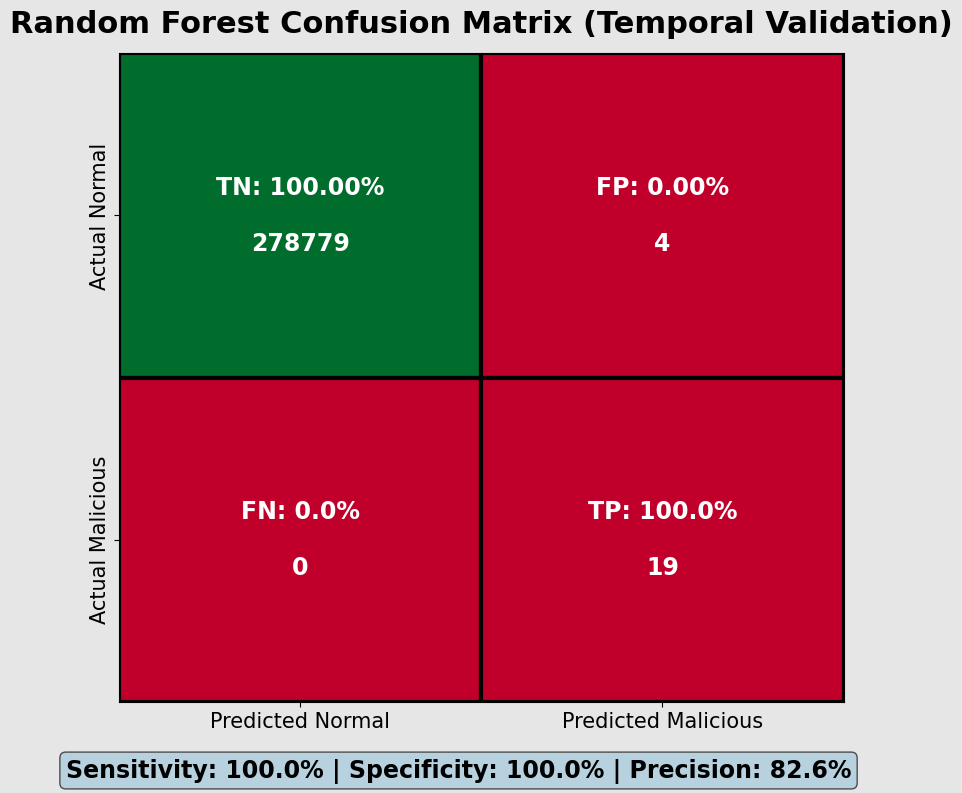

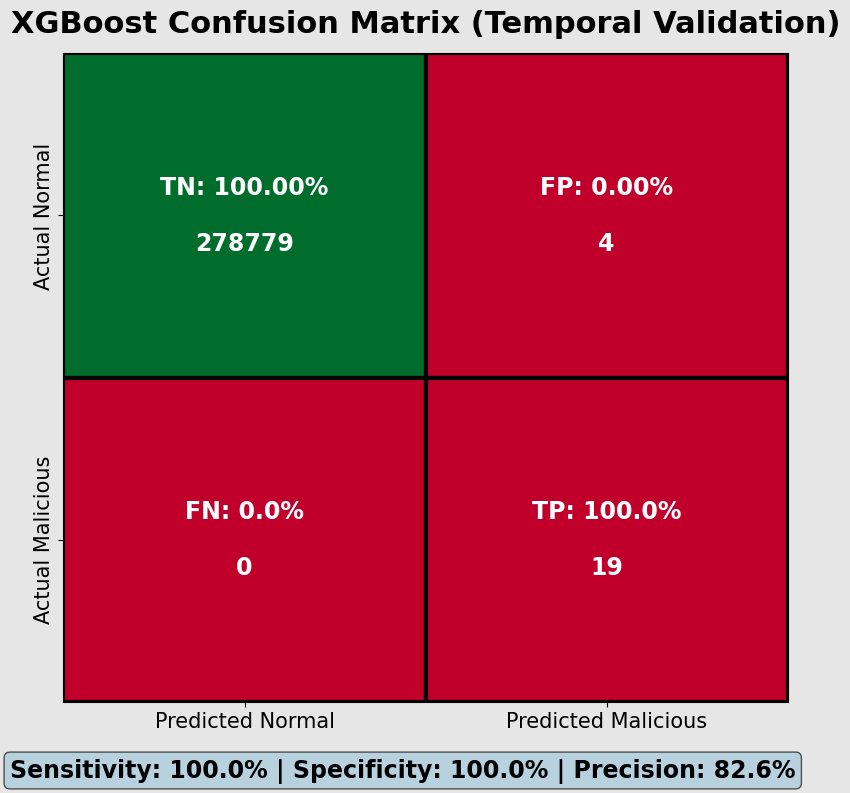

In [8]:
lr.fit(X_train, y_train)
rf.fit(X_train, y_train)
xgb.fit(X_train, y_train)

plot_custom_cm(y_test, lr.predict(X_test), "Logistic Regression Confusion Matrix (Temporal Validation)")
plot_custom_cm(y_test, rf.predict(X_test), "Random Forest Confusion Matrix (Temporal Validation)")
plot_custom_cm(y_test, xgb.predict(X_test), "XGBoost Confusion Matrix (Temporal Validation)")